# Notebook 4 — AI Models II: Object Detection

**Digital Humanities · Image Processing for Museums & Cultural Heritage**

Classification (Notebook 3) gives one label for the *whole image*.
**Object detection** answers a richer question: *what* is in the image,
*where*, and *how many* — each object gets a labeled bounding box.

Museum & DH use cases:
- Counting and locating **figures in artworks** (iconography at scale)
- **Visitor analytics** from gallery photos (with serious ethical caveats!)
- Finding every image containing a **boat / horse / crown** in a 100k-image archive

In this notebook:
1. **YOLO** — the fast, modern one-shot detector
2. **Faster R-CNN** — the classic two-stage detector, for comparison
3. Confidence thresholds and their consequences
4. Detection **on paintings** — does it transfer to art?
5. **FiftyOne** — a professional tool to browse datasets + predictions

> ⏳ First run downloads YOLO (~6 MB) and Faster R-CNN (~160 MB) weights.

In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image

DATA = Path("..") / "data" / "raw"
OUT = Path("..") / "outputs"

device = ("mps" if torch.backends.mps.is_available()
          else "cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: mps


## 1. YOLO: detection in two lines

**YOLO** ("You Only Look Once") processes the entire image in a single
neural-network pass — fast enough for live video. We use a small pretrained
model trained on **COCO** (80 everyday object classes: person, car, dog,
bench, vase...).

100%|██████████| 6.25M/6.25M [00:00<00:00, 30.9MB/s]

image 1/1 /Users/xkaria/Course/image/hamsari/notebooks/../data/raw/louvre_crowd.jpg: 384x640 12 persons, 4 cell phones, 50.3ms
Speed: 1.8ms preprocess, 50.3ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)


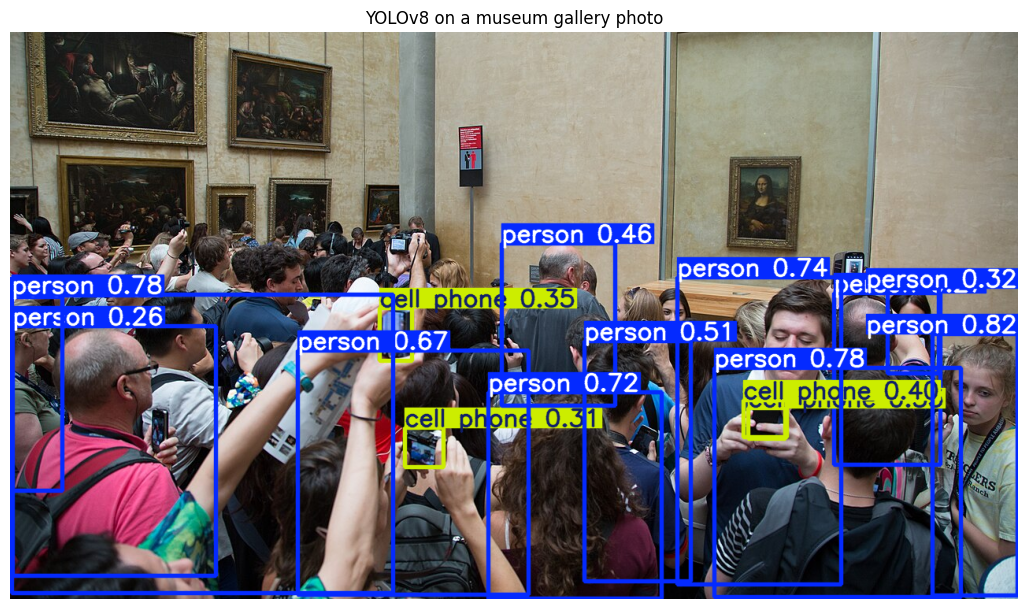

In [4]:
from ultralytics import YOLO

yolo = YOLO("yolov8n.pt")   # n = nano, the smallest variant

results = yolo(str(DATA / "louvre_crowd.jpg"))
plt.figure(figsize=(13, 8))
plt.imshow(results[0].plot()[:, :, ::-1])   # .plot() returns BGR → flip to RGB
plt.axis("off"); plt.title("YOLOv8 on a museum gallery photo")
plt.show()

In [5]:
# The structured results behind the picture:
for box in results[0].boxes:
    cls = yolo.names[int(box.cls)]
    print(f"{cls:12s}  confidence {float(box.conf):.2f}   "
          f"box {[round(v) for v in box.xyxy[0].tolist()]}")

person        confidence 0.82   box [1171, 383, 1280, 716]
person        confidence 0.78   box [2, 333, 486, 713]
person        confidence 0.78   box [894, 427, 1208, 717]
person        confidence 0.74   box [848, 312, 1055, 701]
person        confidence 0.72   box [607, 458, 828, 719]
person        confidence 0.67   box [365, 404, 659, 715]
person        confidence 0.51   box [729, 393, 865, 698]
person        confidence 0.46   box [624, 268, 769, 474]
cell phone    confidence 0.40   box [932, 467, 986, 514]
cell phone    confidence 0.35   box [469, 350, 510, 417]
cell phone    confidence 0.33   box [937, 477, 984, 516]
person        confidence 0.32   box [0, 337, 66, 582]
person        confidence 0.32   box [1115, 325, 1179, 434]
cell phone    confidence 0.31   box [502, 503, 551, 553]
person        confidence 0.27   box [1047, 331, 1182, 550]
person        confidence 0.26   box [4, 374, 261, 691]


Every detection is **data**: a class, a confidence score, and coordinates.
That's what makes detection useful at scale — you can put a million of
these rows in a database and *query* your image collection like a catalog.

## 2. The confidence threshold: a curatorial decision

Detectors report a confidence for each box. Where you set the cutoff is a
**trade-off you must own**, not a technical detail:

- Low threshold → finds more (good for *discovery*), more false alarms
- High threshold → fewer mistakes (good for *automatic metadata*), misses more

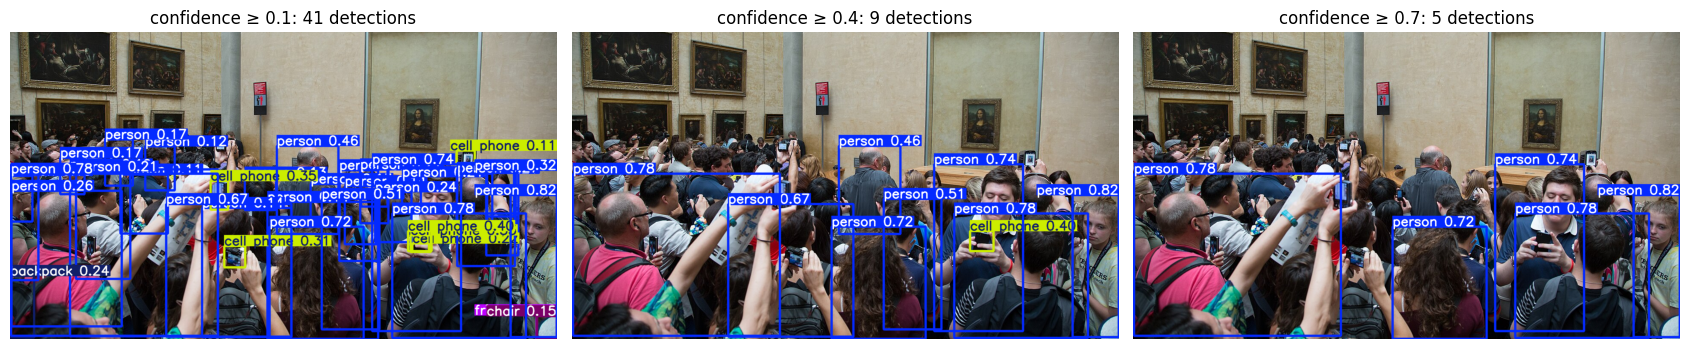

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, conf in zip(axes, [0.1, 0.4, 0.7]):
    res = yolo(str(DATA / "louvre_crowd.jpg"), conf=conf, verbose=False)
    ax.imshow(res[0].plot()[:, :, ::-1]); ax.axis("off")
    ax.set_title(f"confidence ≥ {conf}: {len(res[0].boxes)} detections")
plt.tight_layout(); plt.show()

## 3. Faster R-CNN: the two-stage classic

**Faster R-CNN** (2015) first proposes candidate regions, then classifies
each. It's slower than YOLO but often more precise — and it shows students
that "AI object detection" is a family of architectures, not one product.

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /Users/xkaria/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:05<00:00, 33.2MB/s] 
/Users/xkaria/anaconda3/envs/image-extractor-env/lib/python3.12/site-packages/torchvision/utils.py:233: UserWarning: Argument 'font_size' will be ignored since 'font' is not set.
  warnings.warn("Argument 'font_size' will be ignored since 'font' is not set.")


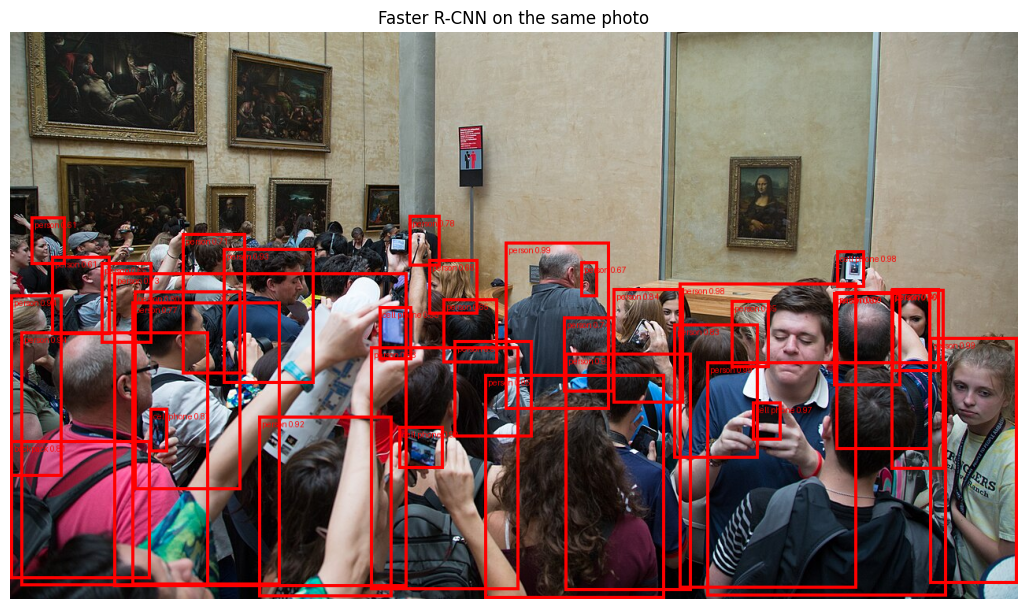

In [7]:
from torchvision.models.detection import (FasterRCNN_ResNet50_FPN_Weights,
                                          fasterrcnn_resnet50_fpn)
from torchvision.utils import draw_bounding_boxes

frcnn_weights = FasterRCNN_ResNet50_FPN_Weights.DEFAULT
frcnn = fasterrcnn_resnet50_fpn(weights=frcnn_weights).eval()
coco_names = frcnn_weights.meta["categories"]

def frcnn_detect(file, threshold=0.6):
    image = Image.open(DATA / file).convert("RGB")
    tensor = torch.from_numpy(np.array(image)).permute(2, 0, 1)
    with torch.no_grad():
        pred = frcnn([tensor.float() / 255])[0]
    keep = pred["scores"] > threshold
    labels = [f"{coco_names[i]} {s:.2f}"
              for i, s in zip(pred["labels"][keep], pred["scores"][keep])]
    boxed = draw_bounding_boxes(tensor, pred["boxes"][keep], labels,
                                colors="red", width=4, font_size=24)
    return boxed.permute(1, 2, 0).numpy()

plt.figure(figsize=(13, 8))
plt.imshow(frcnn_detect("louvre_crowd.jpg"))
plt.axis("off"); plt.title("Faster R-CNN on the same photo")
plt.show()

## 4. Detection on artworks: the domain gap, again

COCO contains *photographs*. What happens when we point these detectors at
*paintings*? Surprisingly often they still find "person" — painted people
look enough like photographed ones. But expect stranger results too.

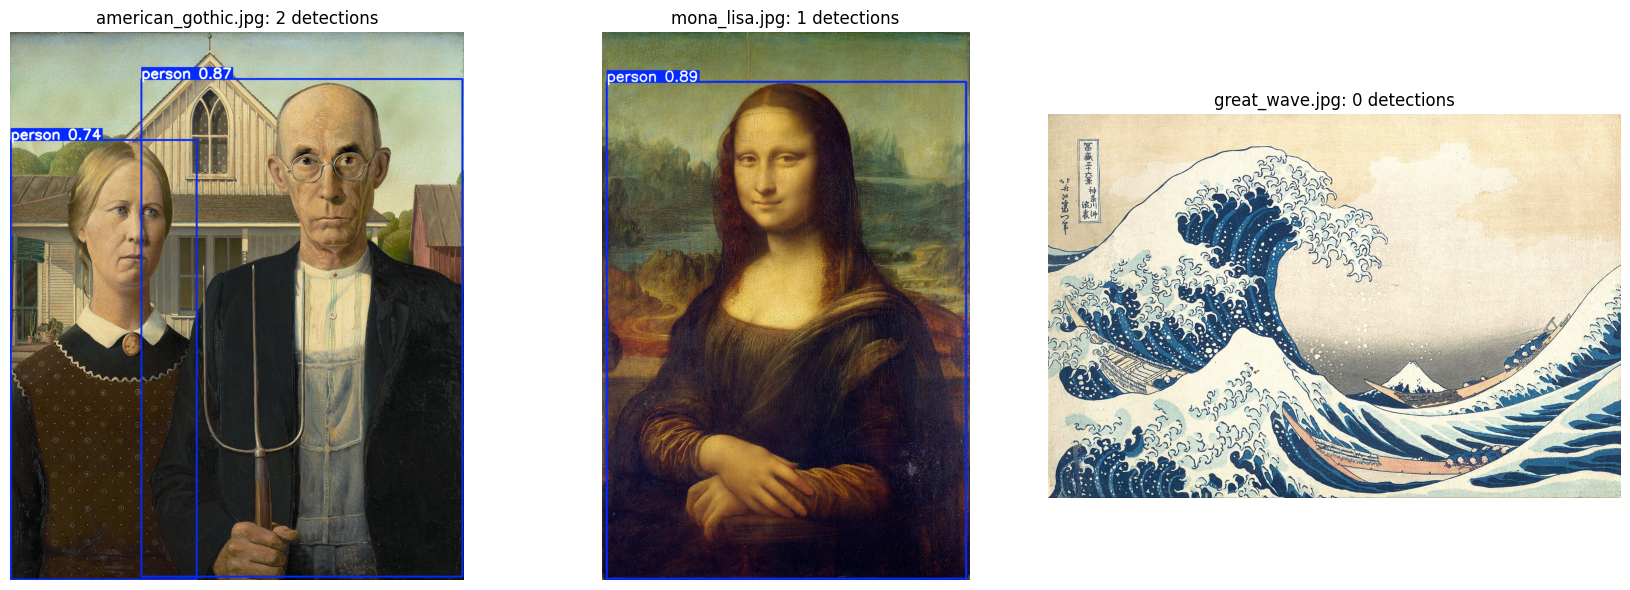

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(17, 6))
for ax, file in zip(axes, ["american_gothic.jpg", "mona_lisa.jpg", "great_wave.jpg"]):
    res = yolo(str(DATA / file), conf=0.25, verbose=False)
    ax.imshow(res[0].plot()[:, :, ::-1]); ax.axis("off")
    ax.set_title(f"{file}: {len(res[0].boxes)} detections")
plt.tight_layout(); plt.show()

Research projects in the DH world fine-tune detectors on *artworks*
specifically (e.g. detecting saints' attributes, animals in medieval
marginalia, or faces in historical photo archives). The recipe is the same
transfer learning we used in Notebook 3 — `yolo.train(data=...)` with a
small annotated dataset. Annotation tools: CVAT, Label Studio, Roboflow.

⚖️ **Ethics checkpoint** — detection of *people* (visitors, photo archives)
is personal-data processing. Before deploying: Is there consent? Could the
data identify individuals? GDPR and museum ethics codes apply to AI
pipelines exactly as they do to CCTV.

## 5. FiftyOne: exploring datasets and predictions professionally

Matplotlib is fine for one image. For a *collection*, use
**FiftyOne** (by Voxel51): an interactive app to browse images, overlay
predictions, filter by confidence, and find annotation errors.

> ⏳ The first import sets up FiftyOne's local database (one-time).
> The app opens embedded below the cell (or in a browser tab).

In [9]:
import fiftyone as fo

# Build a dataset from our folder and attach YOLO predictions to every image
if fo.dataset_exists("heritage-demo"):
    fo.delete_dataset("heritage-demo")
dataset = fo.Dataset.from_images_dir(str(DATA.resolve()), name="heritage-demo")

for sample in dataset:
    res = yolo(sample.filepath, conf=0.25, verbose=False)[0]
    w, h = res.orig_shape[1], res.orig_shape[0]
    detections = []
    for box in res.boxes:
        x1, y1, x2, y2 = box.xyxy[0].tolist()
        detections.append(fo.Detection(
            label=yolo.names[int(box.cls)],
            # FiftyOne wants [x, y, width, height] in relative (0–1) coords
            bounding_box=[x1 / w, y1 / h, (x2 - x1) / w, (y2 - y1) / h],
            confidence=float(box.conf),
        ))
    sample["yolo"] = fo.Detections(detections=detections)
    sample.save()

print(dataset)

/Users/xkaria/anaconda3/envs/image-extractor-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


 100% |███████████████████| 10/10 [14.1ms elapsed, 0s remaining, 707.9 samples/s]    
Name:        heritage-demo
Media type:  image
Num samples: 10
Persistent:  False
Tags:        []
Sample fields:
    id:               fiftyone.core.fields.ObjectIdField
    filepath:         fiftyone.core.fields.StringField
    tags:             fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:         fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:       fiftyone.core.fields.DateTimeField
    last_modified_at: fiftyone.core.fields.DateTimeField
    yolo:             fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)


In [10]:
# Launch the interactive app — click any image, toggle the 'yolo' overlay,
# and use the sidebar to filter by label or confidence.
session = fo.launch_app(dataset, auto=False)
session


Could not connect session, trying again in 10 seconds

Session launched. Run `session.show()` to open the App in a cell output.


Dataset:          heritage-demo
Media type:       image
Num samples:      10
Selected samples: 0
Selected labels:  0
Session URL:      http://localhost:5151/

Things to try in the app:
- Filter to only `person` detections — which artworks contain "people"?
- Drag the confidence slider and watch boxes appear/disappear (§2, live!)
- Imagine this with 50,000 archive scans: this is how you *audit* an AI
  model before trusting its output in your catalog.

In [9]:
# When you're done exploring:
# session.close()

## ✏️ Exercises

1. Run YOLO on a photo from your own phone. Which COCO classes appear?
2. Compare YOLO and Faster R-CNN on `american_gothic.jpg` at the same
   threshold. Which painted objects does each find/miss?
3. In FiftyOne, sort samples by number of detections. Which heritage image
   "looks most like COCO" to the model — and why might that be?
4. Critical discussion: your museum wants to auto-tag 200,000 archive
   photos with detected objects. Draft three quality-control rules using
   what you learned about confidence thresholds and the domain gap.

**Next:** Notebook 5 — the other direction: AI that *creates* images, and
what that means for museums.